In [1]:
from google.colab.patches import cv2_imshow
from google.colab import drive
import numpy as np
import cv2
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

Mounted at /content/gdrive


(256, 256, 3)


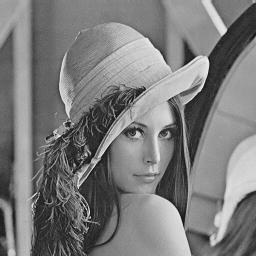

In [2]:
img = cv2.imread('/content/gdrive/My Drive/IP/Images/lena256.jpg')

print(img.shape)
gimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#plt.imshow(gimg, cmap='gray')
cv2_imshow(gimg)

In [3]:
def saturation(value):
  if(value > 255):
    return 255
  elif(value < 0):
    value = 0
    return value
  else:
    return value

In [8]:
Kernel3 = np.ones((3,3), np.float32)/9
Kernel5 = np.ones((5,5), np.float32)/25
Kernel7 = np.ones((7,7), np.float32)/49

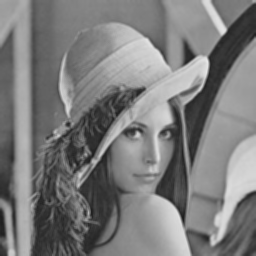

In [10]:
output = cv2.filter2D(gimg, -1, Kernel3)
cv2_imshow(output)

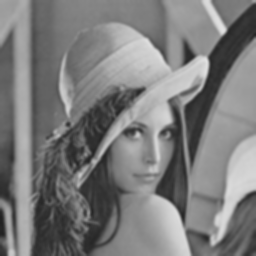

In [ ]:
output = cv2.filter2D(output, -1, Kernel3)
cv2_imshow(output)

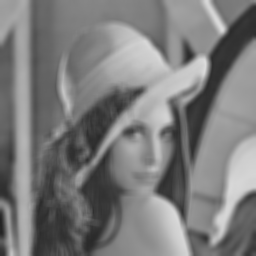

In [11]:
output = cv2.filter2D(gimg, -1, Kernel7)
cv2_imshow(output)

In [ ]:
gOut = np.zeros((gimg.shape[0], gimg.shape[1]), dtype=np.ubyte)

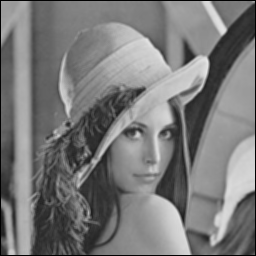

In [ ]:
for h in range(1, gimg.shape[0]-1):
  for w in range(1, gimg.shape[1]-1):
    sum = 0
    for i in range(-1, 2):
      for j in range(-1, 2):
        sum += gimg[h+i, w+j] * Kernel3[i+1, j+1]
    sum = saturation(sum)
    gOut[h,w] = sum


cv2_imshow(gOut)

In [14]:
Kernel3[0][0] = -1/9
Kernel3[0][1] = -1/9
Kernel3[0][2] = -1/9
Kernel3[1][0] = -1/9
Kernel3[1][1] = 8/9
Kernel3[1][2] = -1/9
Kernel3[2][0] = -1/9
Kernel3[2][1] = -1/9
Kernel3[2][2] = -1/9

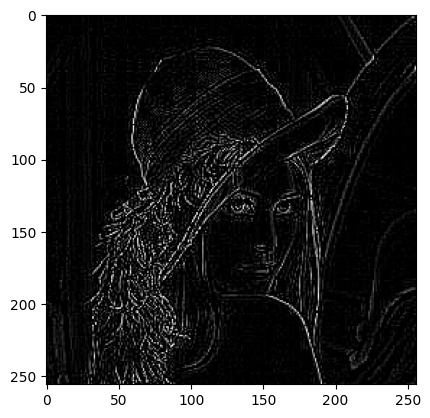

In [16]:
output = cv2.filter2D(gimg, -1, Kernel3)
#cv2_imshow(output)
output = output * 5
plt.imshow(output, cmap='gray')

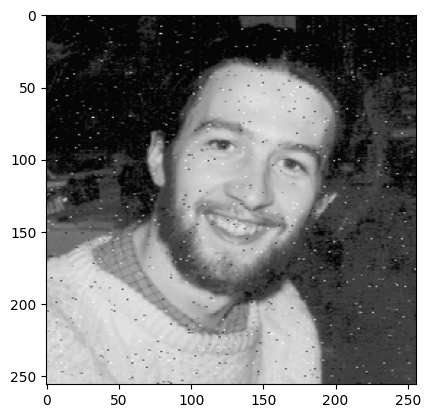

In [28]:
img = cv2.imread('/content/gdrive/My Drive/IP/Images/fcesnoise.bmp')
#img = cv2.imread('/content/gdrive/My Drive/IP/Images/LenaG1.jpg')
gimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gimg, cmap='gray')
#cv2_imshow(gimg)

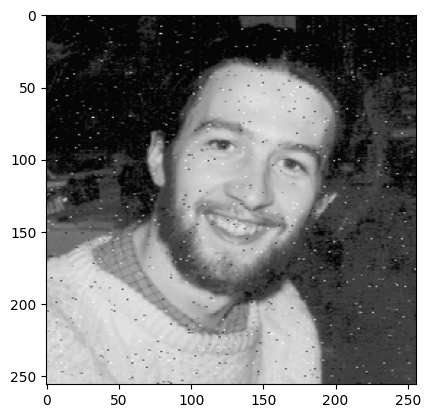

In [29]:
outimg = cv2.blur(gimg, (3,3))
#cv2_imshow(outimg)
plt.imshow(gimg, cmap='gray')

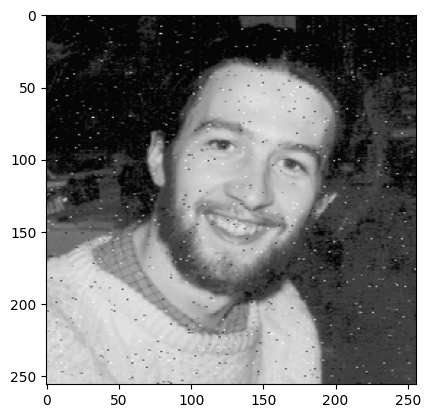

In [32]:
outimg = cv2.medianBlur(gimg,3)
#cv2_imshow(outimg)
plt.imshow(gimg, cmap='gray')